In [1]:
import pandas as pd
import numpy as np
from datetime import datetime
import os

import clickhouse_connect

# Show all rows
pd.set_option("display.max_rows", None)

# Show all columns
pd.set_option("display.max_columns", None)

# Make sure wide DataFrames don't wrap
pd.set_option("display.width", None)

# Show the full content of each column (no '...')
pd.set_option("display.max_colwidth", None)

In [2]:
client = clickhouse_connect.get_client(
    host='yaujulxk39.eastus2.azure.clickhouse.cloud',      # or server IP
    port=8443,             # HTTP port (default)
    username='default',
    password='~gZjRLjjOJh1i',
    database='Competitive_Analysis'
)

In [3]:
# ---- Query ----
df_hum_hist = client.query_df("""
    SELECT *
    FROM Competitive_Analysis.DRGHistoricalReviewInformation
    WHERE Client = 'Hum'
""")
df_hum_hist.shape

(76355, 291)

In [4]:
# -------------------------------------------------
# Initial shape of the dataset
# -------------------------------------------------
df_hum = df_hum_hist.copy()

print(df_hum.shape)  

df_hum = df_hum[df_hum['InitialDenialType'] == 'Substantive']
print(df_hum.shape) 

# -------------------------------------------------
# Identify valid Group_Type values
# -------------------------------------------------

group_type_unique = df_hum['Group_Type'].dropna().unique()
print(group_type_unique) 

# -------------------------------------------------
# Filter dataset to only valid Group_Type rows
# Use .copy() to avoid SettingWithCopyWarning
# -------------------------------------------------
df_hum_group_type = df_hum[df_hum['Group_Type'].isin(group_type_unique)].copy()
print(df_hum_group_type.shape) 

# -------------------------------------------------
# Calculate ADRG length
# -------------------------------------------------
df_hum_group_type.loc[:, 'len_adrg'] = (
    df_hum_group_type['ADRG'].astype(str).str.len()
)

print(df_hum_group_type['len_adrg'].value_counts())
print(df_hum_group_type['Group_Type'].value_counts())

# -------------------------------------------------
# Remove invalid DRG / Group_Type combinations
#   1) Group_Type = '01' and ADRG length = 4
#   2) Group_Type = '10' and ADRG length = 3
# -------------------------------------------------
mask_remove = (
    ((df_hum_group_type['Group_Type'] == '01') & (df_hum_group_type['len_adrg'] == 4)) |
    ((df_hum_group_type['Group_Type'] == '10') & (df_hum_group_type['len_adrg'] == 3))
)

df_hum_drg_rem = df_hum_group_type.loc[~mask_remove].copy()
print(df_hum_drg_rem.shape)

# -------------------------------------------------
# Create a copy of InitialDeterminationDate
# -------------------------------------------------
df_hum_drg_rem.loc[:, 'InitialDeterminationDate_copy'] = (
    df_hum_drg_rem['InitialDeterminationDate']
)

print(
    df_hum_drg_rem['Control_ID']
    .value_counts()
    .sort_values(ascending=False)
    .head()
)

# -------------------------------------------------
# Convert date column to datetime
# -------------------------------------------------
df_hum_drg_rem.loc[:, 'InitialDeterminationDate_copy'] = pd.to_datetime(
    df_hum_drg_rem['InitialDeterminationDate_copy'],
    errors='coerce'
)

# -------------------------------------------------
# Keep latest record per Control_ID
# -------------------------------------------------
df_sorted = df_hum_drg_rem.sort_values(
    'InitialDeterminationDate_copy',
    ascending=False
)

df_hum_latest = df_sorted.drop_duplicates(
    subset='Control_ID',
    keep='first'
).copy()

print(df_hum_latest.shape)

# -------------------------------------------------
# Normalize string columns
# -------------------------------------------------
df_hum_latest.loc[:, 'ADRG'] = (
    df_hum_latest['ADRG'].astype(str).str.strip()
)

df_hum_latest.loc[:, 'PRIM_DX'] = (
    df_hum_latest['PRIM_DX'].astype(str).str.strip().str.upper()
)

df_hum_latest.loc[:, 'InitialDeterminationStatus'] = (
    df_hum_latest['InitialDeterminationStatus']
    .astype(str)
    .str.strip()
    .str.upper()
)

# -------------------------------------------------
# Clean numeric fields
# -------------------------------------------------
df_hum_latest.loc[:, 'IDSavings'] = (
    pd.to_numeric(df_hum_latest['IDSavings'], errors='coerce').fillna(0)
)

df_hum_latest.loc[:, 'LOS'] = (
    pd.to_numeric(df_hum_latest['LOS'], errors='coerce').fillna(0)
)

df_hum_latest.loc[:, 'AGE'] = (
    pd.to_numeric(df_hum_latest['AGE'], errors='coerce')
)

# -------------------------------------------------
# Validate AGE values
# -------------------------------------------------
max_age = df_hum_latest['AGE'].max()

df_hum_latest = df_hum_latest[(
    df_hum_latest['AGE'].between(0, max_age))
].copy()
df_hum_latest.loc[:, 'AGE'] = df_hum_latest['AGE'].astype('Int64')
print(df_hum_latest.shape)

# -------------------------------------------------
# Validate LOS values
# -------------------------------------------------
df_hum_latest.loc[:, 'LOS'] = (
    df_hum_latest['LOS'].astype('Int64')
)

df_hum_latest = df_hum_latest[(df_hum_latest['LOS'] >= 0)].copy()
print(df_hum_latest.shape)

# -------------------------------------------------
# Remove extreme savings outliers
# -------------------------------------------------
df_hum_latest = df_hum_latest[
    df_hum_latest['IDSavings'] < 650000
].reset_index(drop=True)

print(df_hum_latest.shape)

# Date only
df_hum_latest['InitialDeterminationDate_date'] = (
    df_hum_latest['InitialDeterminationDate'].dt.date
)

# Year
df_hum_latest['InitialDetermination_Year'] = (
    df_hum_latest['InitialDeterminationDate'].dt.year
)

df_hum_latest["InitialDeterminationDate_date"] = pd.to_datetime(
    df_hum_latest["InitialDeterminationDate_date"],
    errors="coerce"   # handles bad / empty values safely
)


df_hum_latest['InitialDeterminationStatus_Flag'] = (
    df_hum_latest['InitialDeterminationStatus']
    .str.strip()
    .str.upper()
    .map({
        'APPROVED': 0,
        'DENIED': 1
    })
)


df_hum_latest.shape

(76355, 291)
(76355, 291)
<StringArray>
['01', '10']
Length: 2, dtype: string
(76351, 291)
len_adrg
3    75215
4     1136
Name: count, dtype: int64
Group_Type
01    75214
10     1137
Name: count, dtype: Int64
(76340, 292)
Control_ID
HUPTMR-51356    1
HUPTMR-71671    1
HUPTMR-63729    1
HUPRMR-9433     1
HUPRMR-9418     1
Name: count, dtype: Int64
(76340, 293)
(76339, 293)
(76337, 293)
(76337, 293)


(76337, 296)

In [5]:
df_hum_ms_drg = df_hum_latest[df_hum_latest['Group_Type']=='01']
print(df_hum_ms_drg.shape)

df_hum_ms_drg['len_adrg'].value_counts()

(75206, 296)


len_adrg
3    75206
Name: count, dtype: int64

In [6]:
df = df_hum_ms_drg.copy()

adx_cols = [f"A_DX{i}" for i in range(2, 26)]
apx_cols = [f"A_PX{i}" for i in range(1, 26)]
bdx_cols = [f"B_DX{i}" for i in range(2, 26)]
bpx_cols = [f"B_PX{i}" for i in range(1, 26)]

df["A_DX_List"] = df[adx_cols].values.tolist()
df["A_PX_List"] = df[apx_cols].values.tolist()
df["B_DX_List"] = df[bdx_cols].values.tolist()
df["B_PX_List"] = df[bpx_cols].values.tolist()

# Convert to sorted comma separated values
df["A_DX_List"] = df["A_DX_List"].apply(lambda x: ",".join(sorted([str(i) for i in x if pd.notna(i)])))
df["A_PX_List"] = df["A_PX_List"].apply(lambda x: ",".join(sorted([str(i) for i in x if pd.notna(i)])))
df["B_DX_List"] = df["B_DX_List"].apply(lambda x: ",".join(sorted([str(i) for i in x if pd.notna(i)])))
df["B_PX_List"] = df["B_PX_List"].apply(lambda x: ",".join(sorted([str(i) for i in x if pd.notna(i)])))


def clean_sdx_list(val):
    if pd.isna(val) or val == "":
        return ""
    
    lst = val.split(",")  # split comma-separated values
    cleaned = []
    
    for item in lst:
        item = str(item).upper().strip()       # normalize
        item = item.replace("- MCC", "")       # remove MCC
        item = item.replace("- CC", "")        # remove CC
        item = item.replace("MCC", "")         # safety
        item = item.replace("CC", "")          # safety
        item = item.strip().replace("-", "")   # final cleanup
        cleaned.append(item)
    
    return ",".join(sorted(cleaned))  # sort again and join

df["A_DX_List_Clean"] = df["A_DX_List"].apply(clean_sdx_list)
df["B_DX_List_Clean"] = df["B_DX_List"].apply(clean_sdx_list)

mccandcclist_df = pd.read_excel(r"C:\Arun_MIX\MCCCCList.xlsx")
mccandcclist_df['ICDCode'] = (
    mccandcclist_df['ICDCode']
    .astype(str)
    .str.strip()
    .str.upper()
)
mccandcclist = dict(zip(mccandcclist_df['ICDCode'], mccandcclist_df['MCCorCC']))
print(f"✅ Loaded MCC/CC list with {len(mccandcclist)} entries.")

def map_sdx_types(icd_string, lookup_dict):

    if pd.isna(icd_string) or icd_string == "":
        return []

    icd_list = icd_string.split(",")

    cleaned_list = []
    for code in icd_list:
        code_clean = str(code).strip().upper()
        tag = lookup_dict.get(code_clean, "")
        cleaned_list.append(f"{code_clean} - {tag}")

    return cleaned_list


df['A_DX_Type_list'] = df['A_DX_List_Clean'].apply(lambda x: map_sdx_types(x, mccandcclist))
df['B_DX_Type_list'] = df['B_DX_List_Clean'].apply(lambda x: map_sdx_types(x, mccandcclist))


def split_dx_types(dx_list):

    mcc = [x.split(" - ")[0] for x in dx_list if "- MCC" in x]
    cc = [x.split(" - ")[0] for x in dx_list if "- CC" in x]
    general = [x.split(" - ")[0] for x in dx_list if "- MCC" not in x and "- CC" not in x]

    return pd.Series({
        "A_DX_MCC_Set": ",".join(sorted(mcc)),
        "A_DX_CC_Set": ",".join(sorted(cc)),
        "A_DX_General_Set": ",".join(sorted(general)),
        "A_DX_MCC_Count": len(mcc),
        "A_DX_CC_Count": len(cc),
        "A_DX_General_Count": len(general)
    })


df[[
    "A_DX_MCC_Set",
    "A_DX_CC_Set",
    "A_DX_General_Set",
    "A_DX_MCC_Count",
    "A_DX_CC_Count",
    "A_DX_General_Count"
]] = df["A_DX_Type_list"].apply(split_dx_types)

df.head(1)



✅ Loaded MCC/CC list with 17913 entries.


,Payor,claimid,Client,Control_ID,Claim_Number,PaymentType,Group_Type,Payments,Tax_ID,Provider_ID,HospitalName,LOS,DISP_Code,ADRG,DischargeYear,DischargeMonth,AGE,A_CCCount,A_MCCCount,B_CCCount,B_MCCCount,LOB,MRREQ,MRREC,PRIM_DX,A_DX2,A_DX3,A_DX4,A_DX5,A_DX6,A_DX7,A_DX8,A_DX9,A_DX10,A_DX11,A_DX12,A_DX13,A_DX14,A_DX15,A_DX16,A_DX17,A_DX18,A_DX19,A_DX20,A_DX21,A_DX22,A_DX23,A_DX24,A_DX25,A_POA,A_POA2,A_POA3,A_POA4,A_POA5,A_POA6,A_POA7,A_POA8,A_POA9,A_POA10,A_POA11,A_POA12,A_POA13,A_POA14,A_POA15,A_POA16,A_POA17,A_POA18,A_POA19,A_POA20,A_POA21,A_POA22,A_POA23,A_POA24,A_POA25,A_PX1,A_PX2,A_PX3,A_PX4,A_PX5,A_PX6,A_PX7,A_PX8,A_PX9,A_PX10,A_PX11,A_PX12,A_PX13,A_PX14,A_PX15,A_PX16,A_PX17,A_PX18,A_PX19,A_PX20,A_PX21,A_PX22,A_PX23,A_PX24,A_PX25,B_DISPCode,B_DenialCode,B_DRG,B_PRIMDX,B_DX2,B_DX3,B_DX4,B_DX5,B_DX6,B_DX7,B_DX8,B_DX9,B_DX10,B_DX11,B_DX12,B_DX13,B_DX14,B_DX15,B_DX16,B_DX17,B_DX18,B_DX19,B_DX20,B_DX21,B_DX22,B_DX23,B_DX24,B_DX25,B_POA,B_POA2,B_POA3,B_POA4,B_POA5,B_POA6,B_POA7,B_POA8,B_POA9,B_POA10,B_POA11,B_POA12,B_POA13,B_POA14,B_POA15,B_POA16,B_POA17,B_POA18,B_POA19,B_POA20,B_POA21,B_POA22,B_POA23,B_POA24,B_POA25,B_PX1,B_PX2,B_PX3,B_PX4,B_PX5,B_PX6,B_PX7,B_PX8,B_PX9,B_PX10,B_PX11,B_PX12,B_PX13,B_PX14,B_PX15,B_PX16,B_PX17,B_PX18,B_PX19,B_PX20,B_PX21,B_PX22,B_PX23,B_PX24,B_PX25,A_PRIMDX_Desc,A_DX2_Desc,A_DX3_Desc,A_DX4_Desc,A_DX5_Desc,A_DX6_Desc,A_DX7_Desc,A_DX8_Desc,A_DX9_Desc,A_DX10_Desc,A_DX11_Desc,A_DX12_Desc,A_DX13_Desc,A_DX14_Desc,A_DX15_Desc,A_DX16_Desc,A_DX17_Desc,A_DX18_Desc,A_DX19_Desc,A_DX20_Desc,A_DX21_Desc,A_DX22_Desc,A_DX23_Desc,A_DX24_Desc,A_DX25_Desc,A_PX1_Desc,A_PX2_Desc,A_PX3_Desc,A_PX4_Desc,A_PX5_Desc,A_PX6_Desc,A_PX7_Desc,A_PX8_Desc,A_PX9_Desc,A_PX10_Desc,A_PX11_Desc,A_PX12_Desc,A_PX13_Desc,A_PX14_Desc,A_PX15_Desc,A_PX16_Desc,A_PX17_Desc,A_PX18_Desc,A_PX19_Desc,A_PX20_Desc,A_PX21_Desc,A_PX22_Desc,A_PX23_Desc,A_PX24_Desc,A_PX25_Desc,B_PRIMDX_Desc,B_DX2_Desc,B_DX3_Desc,B_DX4_Desc,B_DX5_Desc,B_DX6_Desc,B_DX7_Desc,B_DX8_Desc,B_DX9_Desc,B_DX10_Desc,B_DX11_Desc,B_DX12_Desc,B_DX13_Desc,B_DX14_Desc,B_DX15_Desc,B_DX16_Desc,B_DX17_Desc,B_DX18_Desc,B_DX19_Desc,B_DX20_Desc,B_DX21_Desc,B_DX22_Desc,B_DX23_Desc,B_DX24_Desc,B_DX25_Desc,B_PX1_Desc,B_PX2_Desc,B_PX3_Desc,B_PX4_Desc,B_PX5_Desc,B_PX6_Desc,B_PX7_Desc,B_PX8_Desc,B_PX9_Desc,B_PX10_Desc,B_PX11_Desc,B_PX12_Desc,B_PX13_Desc,B_PX14_Desc,B_PX15_Desc,B_PX16_Desc,B_PX17_Desc,B_PX18_Desc,B_PX19_Desc,B_PX20_Desc,B_PX21_Desc,B_PX22_Desc,B_PX23_Desc,B_PX24_Desc,B_PX25_Desc,InitialDeterminationDate,InitialDenialType,InitialDeterminationStatus,IDSavings,AdjustedSavings,DXRemoved_AtoB,PRIMDX_DownCoded,InitialCoder,InitialCoder_Employer,InitialCoderID,InitialDoctor,InitialDoctorID,InitialProcessor,InitialProcessorID,len_adrg,InitialDeterminationDate_copy,InitialDeterminationDate_date,InitialDetermination_Year,InitialDeterminationStatus_Flag,A_DX_List,A_PX_List,B_DX_List,B_PX_List,A_DX_List_Clean,B_DX_List_Clean,A_DX_Type_list,B_DX_Type_list,A_DX_MCC_Set,A_DX_CC_Set,A_DX_General_Set,A_DX_MCC_Count,A_DX_CC_Count,A_DX_General_Count
0,Strat,1265742,Hum,HUPTMR-67499,820252450252252,PostPay,01,15464.79,455055149,455055149A,ST ANTHONY SHAWNEE HOSPITAL IN,7,01-ROUTINE/HOME,616,2025,8,52,7,3,7,3,MCD93,2025-11-19,NaT,E11621,G928 - MCC,Z5941,Z5982,Z5986,G9341 - MCC,L97419 - CC,M86171 - CC,M869 - CC,L02611 - CC,E88819,E1140,F3181 - CC,F1511,F1010,E039,I10,B1920,R45851 - CC,Z5900 - CC,E1165,F209,L97519,E1110 - MCC,Z794,Y,Y,<NA>,<NA>,<NA>,Y,Y,Y,Y,Y,Y,Y,Y,Y,Y,Y,Y,Y,Y,<NA>,Y,Y,Y,Y,<NA>,0Y6R0Z0,0JBQ0ZZ,0KBV0ZZ,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,01-ROUTINE/HOME,<NA>,616,E11621,G928 - MCC,Z5941,Z5982,Z5986,G9341 - MCC,L97419 - CC,M86171 - CC,M869 - CC,L02611 - CC,E88819,E1140,F3181 - CC,F1511,F1010,E039,I10,B1920,R45851 - CC,Z5900 - CC,E1165,F209,L97519,E1110 - MCC,Z794,Y,Y,<NA>,<NA>,<NA>,Y,Y,Y,Y,Y,Y,Y,Y,Y,Y,Y,Y,Y,Y,<NA>,Y,Y,Y,Y,<NA>,0Y6R0Z0,0JBQ0ZZ,0KBV0ZZ,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<N

In [7]:
df_with_sdx = df[~(df['A_DX_List'].notna() & (df['A_DX_List'].str.len() == 0))]
print(df_with_sdx.shape)

(73436, 310)


In [9]:
df_post = df_with_sdx[df_with_sdx['PaymentType']=='PostPay']
print(df_post.shape)

(64476, 310)


In [10]:
df_post['InitialDeterminationStatus'].value_counts()

InitialDeterminationStatus
APPROVED    56537
DENIED       7939
Name: count, dtype: Int64

In [8]:
selected_cols = [
    "Payments","AGE","Provider_ID",
     "LOS", "ADRG", "PRIM_DX","A_DX_MCC_Set", "A_DX_CC_Set", "A_DX_General_Set","A_DX_MCC_Count",
     "A_DX_CC_Count","A_DX_General_Count","A_PX_List",
    "InitialDeterminationStatus"
]

df_new = df_with_sdx[selected_cols].copy()
df_new.shape

(73436, 14)

In [9]:
df_new['MCC_flag'] = df_new['A_DX_MCC_Set'].apply(
    lambda x: 0 if pd.isna(x) or str(x).strip() == "" else 1
)

df_new['CC_flag'] = df_new['A_DX_CC_Set'].apply(
    lambda x: 0 if pd.isna(x) or str(x).strip() == "" else 1
)

df_new['Gen_flag'] = df_new['A_DX_General_Set'].apply(
    lambda x: 0 if pd.isna(x) or str(x).strip() == "" else 1
)

In [10]:
df_new['InitialDeterminationStatus'].value_counts(normalize=True)

InitialDeterminationStatus
APPROVED    0.879991
DENIED      0.120009
Name: proportion, dtype: Float64

In [14]:
df_new.head(1)

,Payments,AGE,Provider_ID,LOS,ADRG,PRIM_DX,A_DX_MCC_Set,A_DX_CC_Set,A_DX_General_Set,A_DX_MCC_Count,A_DX_CC_Count,A_DX_General_Count,A_PX_List,InitialDeterminationStatus,MCC_flag,CC_flag,Gen_flag
0,15464.79,52,455055149A,7,616,E11621,"E1110,G928,G9341","F3181,L02611,L97419,M86171,M869,R45851","B1920,E039,E1140,E1165,E88819,F1010,F1511,F209,I10,L97519,Z5900,Z5941,Z5982,Z5986,Z794",3,6,15,"0JBQ0ZZ,0KBV0ZZ,0Y6R0Z0",APPROVED,1,1,1


# best

C:\Users\arunkumara\AppData\Local\Temp\8\ipykernel_17596\2863393885.py:74: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  test[col + "_enc"].fillna(global_mean, inplace=True)
C:\Users\arunkumara\AppData\Local\Temp\8\ipykernel_17596\2863393885.py:74: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves

              precision    recall  f1-score   support

           0       0.94      0.82      0.88     12925
           1       0.33      0.64      0.43      1763

    accuracy                           0.80     14688
   macro avg       0.63      0.73      0.65     14688
weighted avg       0.87      0.80      0.82     14688

ROC-AUC: 0.800529539612341


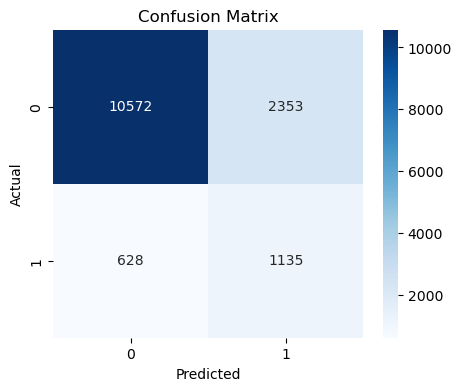

'explainer = shap.Explainer(model, X_train)\nshap_values = explainer(X_test)\n\nshap.summary_plot(shap_values, X_test, feature_names=features)\nshap.plots.bar(shap_values)'

In [14]:
# ============================================================
# 🔥 1. SETUP
# ============================================================

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import seaborn as sns
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
import shap

df = df_new.copy()

# Target
df['target'] = df['InitialDeterminationStatus'].map({
    "APPROVED": 0,
    "DENIED": 1
})


num_cols = ["Payments", "LOS", "AGE"]

# Convert to float (IMPORTANT FIX)
df[num_cols] = df[num_cols].astype(float)

# ============================================================
# ✂️ 2. OUTLIER CAPPING
# ============================================================

num_cols = ["Payments", "LOS", "AGE"]

df[num_cols] = df[num_cols].astype(float)  # ✅ Fix

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = df[col].clip(lower, upper)

# ============================================================
# 🔄 3. LOG TRANSFORM
# ============================================================

df["Payments_log"] = np.log1p(df["Payments"])
df["LOS_log"] = np.log1p(df["LOS"])

# ============================================================
# 🎯 4. TRAIN-TEST SPLIT
# ============================================================

train_df, test_df = train_test_split(
    df, test_size=0.2, random_state=42, stratify=df['target']
)

# ============================================================
# 🧠 5. TARGET ENCODING (ADRG + PRIM_DX)
# ============================================================

def target_encode(train, test, col):
    mapping = train.groupby(col)['target'].mean()
    
    train[col + "_enc"] = train[col].map(mapping)
    test[col + "_enc"] = test[col].map(mapping)
    
    # handle unseen categories
    global_mean = train['target'].mean()
    test[col + "_enc"].fillna(global_mean, inplace=True)
    
    return train, test

train_df, test_df = target_encode(train_df, test_df, "ADRG")
train_df, test_df = target_encode(train_df, test_df, "PRIM_DX")

# ============================================================
# 🧠 6. STATISTICAL EMBEDDING FUNCTIONS
# ============================================================

def explode_column(df, col):
    temp = df[[col, 'target']].dropna()
    temp[col] = temp[col].str.split(',')
    temp = temp.explode(col)
    temp[col] = temp[col].str.strip()
    return temp

def create_code_stats(df, col):
    temp = explode_column(df, col)

    stats = temp.groupby(col).agg({
        'target': ['mean', 'count']
    })

    stats.columns = ['denial_rate', 'freq']
    return stats.reset_index()

def aggregate_features(df, col, stats, prefix):
    stats_dict = stats.set_index(col).to_dict(orient='index')

    def compute(row):
        if pd.isna(row):
            return [0, 0]

        codes = str(row).split(',')
        denial_rates, freqs = [], []

        for code in codes:
            code = code.strip()
            if code in stats_dict:
                denial_rates.append(stats_dict[code]['denial_rate'])
                freqs.append(stats_dict[code]['freq'])

        if len(denial_rates) == 0:
            return [0, 0]

        return [np.mean(denial_rates), np.mean(freqs)]

    features = df[col].apply(compute)

    df[f'{prefix}_denial_mean'] = features.apply(lambda x: x[0])
    df[f'{prefix}_freq_mean'] = features.apply(lambda x: x[1])

    return df

# ============================================================
# 🔥 7. BUILD EMBEDDINGS
# ============================================================

cols = ["A_DX_MCC_Set", "A_DX_CC_Set", "A_DX_General_Set", "A_PX_List"]
prefixes = ["MCC", "CC", "GEN", "PX"]

stats_dict = {}

for col in cols:
    stats_dict[col] = create_code_stats(train_df, col)

for col, prefix in zip(cols, prefixes):
    train_df = aggregate_features(train_df, col, stats_dict[col], prefix)

for col, prefix in zip(cols, prefixes):
    test_df = aggregate_features(test_df, col, stats_dict[col], prefix)

# ============================================================
# 🎯 8. FINAL FEATURES (UPDATED)
# ============================================================

features = [
    "Payments","Payments_log",
    "LOS","LOS_log",
    "AGE",

    # NEW FEATURES
    "ADRG_enc",
    "PRIM_DX_enc",

    # EMBEDDINGS
    "MCC_denial_mean","MCC_freq_mean",
    "CC_denial_mean","CC_freq_mean",
    "GEN_denial_mean","GEN_freq_mean",
    "PX_denial_mean","PX_freq_mean"
]

X_train = train_df[features]
X_test = test_df[features]

y_train = train_df["target"]
y_test = test_df["target"]

# ============================================================
# ⚙️ 9. SCALING
# ============================================================

scaler = RobustScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ============================================================
# ⚖️ 10. IMBALANCE HANDLING
# ============================================================

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

# ============================================================
# 🚀 11. MODEL
# ============================================================

model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='logloss'
)

model.fit(X_train, y_train)

# ============================================================
# 📊 12. EVALUATION
# ============================================================

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ============================================================
# 🔥 13. SHAP
# ============================================================

"""explainer = shap.Explainer(model, X_train)
shap_values = explainer(X_test)

shap.summary_plot(shap_values, X_test, feature_names=features)
shap.plots.bar(shap_values)"""

In [15]:
import pickle

# ============================================================
# 🔥 SAVE TARGET ENCODING MAPS (VERY IMPORTANT)
# ============================================================

encoding_maps = {}
global_mean = train_df['target'].mean()

for col in ["ADRG", "PRIM_DX"]:
    encoding_maps[col] = train_df.groupby(col)['target'].mean().to_dict()

# ============================================================
# 📦 SAVE FULL PIPELINE
# ============================================================

pipeline = {
    "model": model,
    "scaler": scaler,
    "stats_dict": stats_dict,
    "features": features,
    "encoding_maps": encoding_maps,
    "global_mean": global_mean
}

with open("claim_model_USING_stats.pkl", "wb") as f:
    pickle.dump(pipeline, f)

print("✅ Model saved as claim_model.pkl")

✅ Model saved as claim_model.pkl


# predict unknown

In [36]:
cols = [
'CLAIM_Number','CONTROL_ID','SelectionStatus','TRANSDATE','SelectedDate',
'loaddate','modifiedloaddate','CREATEDDATE','MODIFYDATE','PAYMENTS','LOB','LOS',
'REVTYPE','PLAN_NAME','STATE_GROUP','Tax_ID','Provider_ID','HospitalName',
'Age','DischargeYear','DischargeMonth','GROUP_TYPE','HDRG','ADRG',
'A_CCCount','A_MCCCount','PRIM_DX','A_DX2','A_DX3','A_DX4','A_DX5','A_DX6',
'A_DX7','A_DX8','A_DX9','A_DX10','A_DX11','A_DX12','A_DX13','A_DX14','A_DX15',
'A_DX16','A_DX17','A_DX18','A_DX19','A_DX20','A_DX21','A_DX22','A_DX23',
'A_DX24','A_DX25','H_DX','A_PX1','A_PX2','A_PX3','A_PX4','A_PX5','A_PX6',
'A_PX7','A_PX8','A_PX9','A_PX10','A_PX11','A_PX12','A_PX13','A_PX14',
'A_PX15','A_PX16','A_PX17','A_PX18','A_PX19','A_PX20','A_PX21','A_PX22',
'A_PX23','A_PX24','A_PX25'
]
 
query = f"""
SELECT {",".join(cols)}
FROM HumanaBankData
WHERE SelectionStatus  IN ('Selected-Moat Approved',
                    'Selected-moat approved',
                   'Selected')"""
 
df_bank = client.query_df(query)
df_bank.shape

(183378, 77)

In [37]:
df_bank['CLAIM_Number'] = df_bank['CLAIM_Number'].astype(str).str.split('.').str[0]
df_hum_bank_sel_date = df_bank[~(df_bank['SelectedDate'].isnull())]
print(df_hum_bank_sel_date.shape)
 
df_hum_bank_sel_date = df_hum_bank_sel_date.drop_duplicates()
print(df_hum_bank_sel_date.shape)
 
df_hum_bank_sel_date = df_hum_bank_sel_date.rename(columns={'PRIM_DX':'Bank_PDX','ADRG':'Bank_ADRG'})
 
# Make sure date format is correct
df_hum_bank_sel_date['SelectedDate'] = pd.to_datetime(
    df_hum_bank_sel_date['SelectedDate'], errors='coerce'
)
 
# Sort descending and keep latest per CLAIM_Number
df_bank_latest_claim = (
    df_hum_bank_sel_date
        .sort_values('SelectedDate', ascending=False)
        .drop_duplicates('CLAIM_Number', keep='first')
        .reset_index(drop=True)
)
 
print(df_bank_latest_claim.shape)

(183378, 77)
(182886, 77)
(181694, 77)


In [38]:
df_non_audited_claims = df_bank_latest_claim[
    ~df_bank_latest_claim['CLAIM_Number'].isin(df_post['Claim_Number'])
]

df_non_audited_claims.shape

(119879, 77)

In [39]:
df_non_audited_claims.head(1)

,CLAIM_Number,CONTROL_ID,SelectionStatus,TRANSDATE,SelectedDate,loaddate,modifiedloaddate,CREATEDDATE,MODIFYDATE,PAYMENTS,LOB,LOS,REVTYPE,PLAN_NAME,STATE_GROUP,Tax_ID,Provider_ID,HospitalName,Age,DischargeYear,DischargeMonth,GROUP_TYPE,HDRG,Bank_ADRG,A_CCCount,A_MCCCount,Bank_PDX,A_DX2,A_DX3,A_DX4,A_DX5,A_DX6,A_DX7,A_DX8,A_DX9,A_DX10,A_DX11,A_DX12,A_DX13,A_DX14,A_DX15,A_DX16,A_DX17,A_DX18,A_DX19,A_DX20,A_DX21,A_DX22,A_DX23,A_DX24,A_DX25,H_DX,A_PX1,A_PX2,A_PX3,A_PX4,A_PX5,A_PX6,A_PX7,A_PX8,A_PX9,A_PX10,A_PX11,A_PX12,A_PX13,A_PX14,A_PX15,A_PX16,A_PX17,A_PX18,A_PX19,A_PX20,A_PX21,A_PX22,A_PX23,A_PX24,A_PX25
0,820260590497440,<NA>,Selected,2026-03-01,2026-03-04 14:20:41,2026-03-08 15:03:38,2026-03-08 15:07:28,2026-03-04 14:17:55,NaT,9887.46,MEP3I,1,<NA>,Hum,Hum,741109665,000198252B,CHRISTUS SANTA ROSA NEW BRAUNF,74,2026,2,01,0000,065,0,0,I6381,I674,F1020,I10,E782,F17200,M1990,K219,Z716,Z7982,Z79899,Z91148,R29701,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>


In [40]:
df = df_non_audited_claims.copy()

adx_cols = [f"A_DX{i}" for i in range(2, 26)]
apx_cols = [f"A_PX{i}" for i in range(1, 26)]


df["A_DX_List"] = df[adx_cols].values.tolist()
df["A_PX_List"] = df[apx_cols].values.tolist()


# Convert to sorted comma separated values
df["A_DX_List"] = df["A_DX_List"].apply(lambda x: ",".join(sorted([str(i) for i in x if pd.notna(i)])))
df["A_PX_List"] = df["A_PX_List"].apply(lambda x: ",".join(sorted([str(i) for i in x if pd.notna(i)])))



def clean_sdx_list(val):
    if pd.isna(val) or val == "":
        return ""
    
    lst = val.split(",")  # split comma-separated values
    cleaned = []
    
    for item in lst:
        item = str(item).upper().strip()       # normalize
        item = item.replace("- MCC", "")       # remove MCC
        item = item.replace("- CC", "")        # remove CC
        item = item.replace("MCC", "")         # safety
        item = item.replace("CC", "")          # safety
        item = item.strip().replace("-", "")   # final cleanup
        cleaned.append(item)
    
    return ",".join(sorted(cleaned))  # sort again and join

df["A_DX_List_Clean"] = df["A_DX_List"].apply(clean_sdx_list)


mccandcclist_df = pd.read_excel(r"C:\Arun_MIX\MCCCCList.xlsx")
mccandcclist_df['ICDCode'] = (
    mccandcclist_df['ICDCode']
    .astype(str)
    .str.strip()
    .str.upper()
)
mccandcclist = dict(zip(mccandcclist_df['ICDCode'], mccandcclist_df['MCCorCC']))
print(f"✅ Loaded MCC/CC list with {len(mccandcclist)} entries.")

def map_sdx_types(icd_string, lookup_dict):

    if pd.isna(icd_string) or icd_string == "":
        return []

    icd_list = icd_string.split(",")

    cleaned_list = []
    for code in icd_list:
        code_clean = str(code).strip().upper()
        tag = lookup_dict.get(code_clean, "")
        cleaned_list.append(f"{code_clean} - {tag}")

    return cleaned_list


df['A_DX_Type_list'] = df['A_DX_List_Clean'].apply(lambda x: map_sdx_types(x, mccandcclist))



def split_dx_types(dx_list):

    mcc = [x.split(" - ")[0] for x in dx_list if "- MCC" in x]
    cc = [x.split(" - ")[0] for x in dx_list if "- CC" in x]
    general = [x.split(" - ")[0] for x in dx_list if "- MCC" not in x and "- CC" not in x]

    return pd.Series({
        "A_DX_MCC_Set": ",".join(sorted(mcc)),
        "A_DX_CC_Set": ",".join(sorted(cc)),
        "A_DX_General_Set": ",".join(sorted(general)),
        "A_DX_MCC_Count": len(mcc),
        "A_DX_CC_Count": len(cc),
        "A_DX_General_Count": len(general)
    })


df[[
    "A_DX_MCC_Set",
    "A_DX_CC_Set",
    "A_DX_General_Set",
    "A_DX_MCC_Count",
    "A_DX_CC_Count",
    "A_DX_General_Count"
]] = df["A_DX_Type_list"].apply(split_dx_types)

df.head(1)



✅ Loaded MCC/CC list with 17913 entries.


,CLAIM_Number,CONTROL_ID,SelectionStatus,TRANSDATE,SelectedDate,loaddate,modifiedloaddate,CREATEDDATE,MODIFYDATE,PAYMENTS,LOB,LOS,REVTYPE,PLAN_NAME,STATE_GROUP,Tax_ID,Provider_ID,HospitalName,Age,DischargeYear,DischargeMonth,GROUP_TYPE,HDRG,Bank_ADRG,A_CCCount,A_MCCCount,Bank_PDX,A_DX2,A_DX3,A_DX4,A_DX5,A_DX6,A_DX7,A_DX8,A_DX9,A_DX10,A_DX11,A_DX12,A_DX13,A_DX14,A_DX15,A_DX16,A_DX17,A_DX18,A_DX19,A_DX20,A_DX21,A_DX22,A_DX23,A_DX24,A_DX25,H_DX,A_PX1,A_PX2,A_PX3,A_PX4,A_PX5,A_PX6,A_PX7,A_PX8,A_PX9,A_PX10,A_PX11,A_PX12,A_PX13,A_PX14,A_PX15,A_PX16,A_PX17,A_PX18,A_PX19,A_PX20,A_PX21,A_PX22,A_PX23,A_PX24,A_PX25,A_DX_List,A_PX_List,A_DX_List_Clean,A_DX_Type_list,A_DX_MCC_Set,A_DX_CC_Set,A_DX_General_Set,A_DX_MCC_Count,A_DX_CC_Count,A_DX_General_Count
0,820260590497440,<NA>,Selected,2026-03-01,2026-03-04 14:20:41,2026-03-08 15:03:38,2026-03-08 15:07:28,2026-03-04 14:17:55,NaT,9887.46,MEP3I,1,<NA>,Hum,Hum,741109665,000198252B,CHRISTUS SANTA ROSA NEW BRAUNF,74,2026,2,01,0000,065,0,0,I6381,I674,F1020,I10,E782,F17200,M1990,K219,Z716,Z7982,Z79899,Z91148,R29701,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,"E782,F1020,F17200,I10,I674,K219,M1990,R29701,Z716,Z7982,Z79899,Z91148",,"E782,F1020,F17200,I10,I674,K219,M1990,R29701,Z716,Z7982,Z79899,Z91148","[E782 - , F1020 - , F17200 - , I10 - , I674 - CC, K219 - , M1990 - , R29701 - , Z716 - , Z7982 - , Z79899 - , Z91148 - ]",,I674,"E782,F1020,F17200,I10,K219,M1990,R29701,Z716,Z7982,Z79899,Z91148",0,1,11


In [42]:
cols_to_keep = [
    'PAYMENTS', 'Age', 'Provider_ID', 'Bank_ADRG', 'Bank_PDX','LOS',
    'A_DX_List', 'A_PX_List', 'A_DX_List_Clean', 'A_DX_Type_list',
    'A_DX_MCC_Set', 'A_DX_CC_Set', 'A_DX_General_Set',
    'A_DX_MCC_Count', 'A_DX_CC_Count', 'A_DX_General_Count'
]

df_pred = df[cols_to_keep]
df_pred = df_pred.head(200)

df_pred.shape

(200, 16)

In [48]:
df_pred = df_pred.rename(columns={
    "Bank_ADRG": "ADRG",
    "Bank_PDX": "PRIM_DX",
    "PAYMENTS":"Payments",
     "Age":"AGE"
})

In [49]:
df_new.head(1)

,Payments,AGE,Provider_ID,LOS,ADRG,PRIM_DX,A_DX_MCC_Set,A_DX_CC_Set,A_DX_General_Set,A_DX_MCC_Count,A_DX_CC_Count,A_DX_General_Count,A_PX_List,InitialDeterminationStatus,MCC_flag,CC_flag,Gen_flag
0,15464.79,52,455055149A,7,616,E11621,"E1110,G928,G9341","F3181,L02611,L97419,M86171,M869,R45851","B1920,E039,E1140,E1165,E88819,F1010,F1511,F209,I10,L97519,Z5900,Z5941,Z5982,Z5986,Z794",3,6,15,"0JBQ0ZZ,0KBV0ZZ,0Y6R0Z0",APPROVED,1,1,1


In [50]:
df_pred.head(1)

,Payments,AGE,Provider_ID,ADRG,PRIM_DX,LOS,A_DX_List,A_PX_List,A_DX_List_Clean,A_DX_Type_list,A_DX_MCC_Set,A_DX_CC_Set,A_DX_General_Set,A_DX_MCC_Count,A_DX_CC_Count,A_DX_General_Count
0,9887.46,74,000198252B,065,I6381,1,"E782,F1020,F17200,I10,I674,K219,M1990,R29701,Z716,Z7982,Z79899,Z91148",,"E782,F1020,F17200,I10,I674,K219,M1990,R29701,Z716,Z7982,Z79899,Z91148","[E782 - , F1020 - , F17200 - , I10 - , I674 - CC, K219 - , M1990 - , R29701 - , Z716 - , Z7982 - , Z79899 - , Z91148 - ]",,I674,"E782,F1020,F17200,I10,K219,M1990,R29701,Z716,Z7982,Z79899,Z91148",0,1,11


In [51]:
def predict_claim_full(input_dict, model, scaler, stats_dict, features, train_df):
    
    import pandas as pd
    import numpy as np
    
    df_input = pd.DataFrame([input_dict])
    
    # ======================================================
    # 🔄 1. LOG TRANSFORM
    # ======================================================
    df_input["Payments_log"] = np.log1p(df_input["Payments"])
    df_input["LOS_log"] = np.log1p(df_input["LOS"])
    
    # ======================================================
    # 🧠 2. TARGET ENCODING (ADRG, PRIM_DX)
    # ======================================================

    for col in ["ADRG", "PRIM_DX"]:
        mapping = train_df.groupby(col)['target'].mean()
        global_mean = train_df['target'].mean()
        
        df_input[col + "_enc"] = df_input[col].map(mapping)
        
        # FIXED LINE ✅
        df_input[col + "_enc"] = df_input[col + "_enc"].fillna(global_mean)
  
    
    # ======================================================
    # 🧠 3. STATISTICAL EMBEDDING
    # ======================================================
    def apply_embedding(row, col, stats):
        stats_map = stats.set_index(col).to_dict(orient='index')
        
        if pd.isna(row[col]):
            return 0, 0
        
        codes = str(row[col]).split(',')
        
        denial_rates, freqs = [], []
        
        for code in codes:
            code = code.strip()
            if code in stats_map:
                denial_rates.append(stats_map[code]['denial_rate'])
                freqs.append(stats_map[code]['freq'])
        
        if len(denial_rates) == 0:
            return 0, 0
        
        return np.mean(denial_rates), np.mean(freqs)
    
    cols = ["A_DX_MCC_Set", "A_DX_CC_Set", "A_DX_General_Set", "A_PX_List"]
    prefixes = ["MCC", "CC", "GEN", "PX"]
    
    for col, prefix in zip(cols, prefixes):
        d_mean, f_mean = apply_embedding(df_input.iloc[0], col, stats_dict[col])
        
        df_input[f"{prefix}_denial_mean"] = d_mean
        df_input[f"{prefix}_freq_mean"] = f_mean
    
    # ======================================================
    # 🎯 4. SELECT FEATURES
    # ======================================================
    X = df_input[features]
    
    # ======================================================
    # ⚙️ 5. SCALE
    # ======================================================
    X_scaled = scaler.transform(X)
    
    # ======================================================
    # 🚀 6. PREDICTION
    # ======================================================
    prob = model.predict_proba(X_scaled)[0][1]
    pred = model.predict(X_scaled)[0]
    
    label = "DENIED" if pred == 1 else "APPROVED"
    
    return {
        "Prediction": label,
        "Denied_Confidence_%": round(prob * 100, 2),
        "Approved_Confidence_%": round((1 - prob) * 100, 2)
    }

In [52]:
df_pred_copy = df_pred.copy()

results = []

for _, row in df_pred_copy.iterrows():
    
    input_dict = row.to_dict()
    
    output = predict_claim_full(
        input_dict=input_dict,
        model=model,
        scaler=scaler,
        stats_dict=stats_dict,
        features=features,
        train_df=train_df
    )
    
    results.append(output)

# Convert results to DataFrame
df_results = pd.DataFrame(results)

# Merge with original
df_pred_final = pd.concat([df_pred_copy.reset_index(drop=True), df_results], axis=1)

df_pred_final.shape

(200, 19)

In [54]:
df_pred_final['Prediction'].value_counts()

Prediction
DENIED      141
APPROVED     59
Name: count, dtype: int64

In [55]:
df_pred_final.tail(10)

,Payments,AGE,Provider_ID,ADRG,PRIM_DX,LOS,A_DX_List,A_PX_List,A_DX_List_Clean,A_DX_Type_list,A_DX_MCC_Set,A_DX_CC_Set,A_DX_General_Set,A_DX_MCC_Count,A_DX_CC_Count,A_DX_General_Count,Prediction,Denied_Confidence_%,Approved_Confidence_%
190,12373.34,82,000063571A,871,A403,5,"A401,A4159,A4189,B9729,E039,E11649,E785,F17210,I340,I480,J1289,J13,J153,J1569,J158,J440,J441,J9601,N179,R531,R6520,Z1152,Z79899","5A0935A,5A0935A,5A0935A","A401,A4159,A4189,B9729,E039,E11649,E785,F17210,I340,I480,J1289,J13,J153,J1569,J158,J440,J441,J9601,N179,R531,R6520,Z1152,Z79899","[A401 - MCC, A4159 - MCC, A4189 - MCC, B9729 - , E039 - , E11649 - , E785 - , F17210 - , I340 - , I480 - , J1289 - MCC, J13 - MCC, J153 - MCC, J1569 - , J158 - MCC, J440 - CC, J441 - CC, J9601 - MCC, N179 - CC, R531 - , R6520 - MCC, Z1152 - , Z79899 - ]","A401,A4159,A4189,J1289,J13,J153,J158,J9601,R6520","J440,J441,N179","B9729,E039,E11649,E785,F17210,I340,I480,J1569,R531,Z1152,Z79899",9,3,11,DENIED,77.459999,22.540001
191,7068.79,66,000021585R,369,K2091,3,"E669,E860,I4891,I951,K4090,K449,K56609,K5790,N281,Z6831,Z7901,Z9049,Z950",0DB78ZX,"E669,E860,I4891,I951,K4090,K449,K56609,K5790,N281,Z6831,Z7901,Z9049,Z950","[E669 - , E860 - , I4891 - , I951 - , K4090 - , K449 - , K56609 - CC, K5790 - , N281 - , Z6831 - , Z7901 - , Z9049 - , Z950 - ]",,K56609,"E669,E860,I4891,I951,K4090,K449,K5790,N281,Z6831,Z7901,Z9049,Z950",0,1,12,APPROVED,22.920000,77.080002
192,15362.10,81,000021585S,871,A419,3,"D509,D62,E1122,E7800,E860,E8720,I10,K5733,N179,N1832,Z7983,Z7985,Z880",3E03329,"D509,D62,E1122,E7800,E860,E8720,I10,K5733,N179,N1832,Z7983,Z7985,Z880","[D509 - , D62 - CC, E1122 - , E7800 - , E860 - , E8720 - , I10 - , K5733 - MCC, N179 - CC, N1832 - , Z7983 - , Z7985 - , Z880 - ]",K5733,"D62,N179","D509,E1122,E7800,E860,E8720,I10,N1832,Z7983,Z7985,Z880",1,2,10,DENIED,89.279999,10.720000
193,14063.32,76,592496294D,871,A419,4,"D649,E8339,E8342,E861,E871,E8720,E876,E878,F1010,F419,G629,I10,I639,K219,K760,N3000,R296,R29711,Z634,Z96641",,"D649,E8339,E8342,E861,E871,E8720,E876,E878,F1010,F419,G629,I10,I639,K219,K760,N3000,R296,R29711,Z634,Z96641","[D649 - , E8339 - , E8342 - , E861 - , E871 - CC, E8720 - , E876 - , E878 - , F1010 - , F419 - , G629 - , I10 - , I639 - MCC, K219 - , K760 - , N3000 - CC, R296 - , R29711 - , Z634 - , Z96641 - ]",I639,"E871,N3000","D649,E8339,E8342,E861,E8720,E876,E878,F1010,F419,G629,I10,K219,K760,R296,R29711,Z634,Z96641",1,2,17,DENIED,90.739998,9.260000
194,17744.34,85,886000436,871,A419,3,"D638,E039,E8339,E860,E8720,I10,J189,J9601,N179,R6520,Z20822,Z5971,Z603,Z634,Z7982,Z79890,Z79899",,"D638,E039,E8339,E860,E8720,I10,J189,J9601,N179,R6520,Z20822,Z5971,Z603,Z634,Z7982,Z79890,Z79899","[D638 - , E039 - , E8339 - , E860 - , E8720 - , I10 - , J189 - MCC, J9601 - MCC, N179 - CC, R6520 - MCC, Z20822 - , Z5971 - , Z603 - , Z634 - , Z7982 - , Z79890 - , Z79899 - ]","J189,J9601,R6520",N179,"D638,E039,E8339,E860,E8720,I10,Z20822,Z5971,Z603,Z634,Z7982,Z79890,Z79899",3,1,13,DENIED,97.139999,2.860000
195,19265.62,68,862358048,854,A419,4,"B888,E1151,E11621,E1165,E785,I130,I2722,I428,I5022,L03116,M6282,N179,N189,R197,T8781",0JBR0ZZ,"B888,E1151,E11621,E1165,E785,I130,I2722,I428,I5022,L03116,M6282,N179,N189,R197,T8781","[B888 - , E1151 - , E11621 - , E1165 - , E785 - , I130 - CC, I2722 - , I428 - CC, I5022 - CC, L03116 - CC, M6282 - CC, N179 - CC, N189 - , R197 - , T8781 - ]",,"I130,I428,I5022,L03116,M6282,N179","B888,E1151,E11621,E1165,E785,I2722,N189,R197,T8781",0,6,9,DENIED,94.379997,5.620000
196,14571.70,72,884128022A,871,A419,3,"D509,E1122,E1142,E1165,E559,E6601,E785,E860,E8720,E878,F418,G9341,H409,I130,I5042,M109,N179,N1832,N200,N390,R6520,Z6841,Z7982,Z8619",,"D509,E1122,E1142,E1165,E559,E6601,E785,E860,E8720,E878,F418,G9341,H409,I130,I5042,M109,N179,N1832,N200,N390,R6520,Z6841,Z7982,Z8619","[D509 - , E1122 - , E1142 - , E1165 - , E559 - , E6601 - , E785 - , E860 - , E8720 - , E878 - , F418 - , G9341 - MCC, H409 - , I130 - CC, I5042 - CC, M109 - , N179 - CC, N1832 - , N200 - , N3

In [56]:
input_claim = {
    "Payments": 9198.88,
    "LOS": 3,
    "AGE": 66,
    
    "ADRG": "175",
    "PRIM_DX": "I2699",
    
    "A_DX_MCC_Set": "N186",
    "A_DX_CC_Set": "I132,I483,I5032,N2581",
    
    "A_DX_General_Set": "B182,D631,F1421,I2489,I2510,I480,I5A,I672,K219,N250,S301XXA,Z6834,Z7901,Z8616,Z86711,Z86718,Z8674,Z992",
    
    "A_PX_List": "5A1D70Z"
}

In [57]:
result = predict_claim_full(
    input_claim,
    model,
    scaler,
    stats_dict,
    features,
    train_df
)

print(result)

{'Prediction': 'APPROVED', 'Denied_Confidence_%': np.float32(6.31), 'Approved_Confidence_%': np.float32(93.69)}
